# Eksploracyjna Analiza Danych (EDA) 
### Porównanie algorytmów rekomendacyjnych (Filtrowanie Kolaboracyjne, Uczenie Głębokie, Grafowe Sieci Neuronowe) na przykładzie portalu streamingowego

Analiza stanowiąca podstawę do dalszych rozważań nad algorytmami rekomendacyjnymi. Opiera się ona na zbiorze danych Movie Lens 1M. EDA zawiera kolejno: 
1. Podstawowe statystyki opisowe i charakterystyke danych przestrzennych.
2. Badanie zjawiska rzadkości macierzy interakcji.
3. Rozkład aktywności i zjawisko Długiego ogona.
4. Rozkład aktywności użytkowników i problem "zimnego startu".
5. Transformacje ocen na "niejawne sprzężenie zwrotne (potrzebne do algorytmów opartych na uczeniu głębokim).
6. Modelowanie grafu dwudzielnego (wykorzystywane w część dotyczącej grafów wiedzy).
7. Charakterystyka demograficzna (analiza oparta na metadanych).
8. Dynamika czasowa interakcji.

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# Stylizacja wykresów na potrzeby pracy dyplomowej (Academic Style)
ACADEMIC_BLUE = '#1f77b4'
ACADEMIC_GRAY = '#7f7f7f'
LIGHT_BLUE = '#aec7e8'

sns.set_style("ticks")
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

DATASET_VERSION = '1m' # Możliwość zmiany na '1m'
data_dir = '../data'
df_ratings = pd.read_csv(f'{data_dir}/movielens_{DATASET_VERSION}_ratings.csv')

### 1. Podstawowe statystyki opisowe i charakterystyka przestrzeni danych

Każdy system rekomendacyjny operuje w przestrzeni matematycznej zdefiniowanej przez zbiór użytkowników $\mathcal{U}$, zbiór elementów (filmów) $\mathcal{I}$ oraz zbiór historycznych interakcji $\mathcal{E}$. Ustalenie dokładnych wymiarów tej przestrzeni jest niezbędne przed procesem uczenia maszynowego. Wymiarowość determinuje rozmiar warstw osadzeń (Embedding Layers) w architekturach takich jak NCF czy LightGCN. Celem jest zbadanie bazowego rozmiaru środowiska testowego.

In [110]:
n_users = df_ratings['user_id'].nunique()
n_items = df_ratings['item_id'].nunique()
n_interactions = len(df_ratings)

stats_summary = pd.DataFrame({
    'Parametr': ['Liczba użytkowników |U|', 'Liczba filmów |I|', 'Suma interakcji |E|'],
    'Wartość': [n_users, n_items, n_interactions]
})
display(stats_summary)

,Parametr,Wartość
0,Liczba użytkowników |U|,6040
1,Liczba filmów |I|,3706
2,Suma interakcji |E|,1000209



>W zbiorze mamy do czynienia z ponad milionem interakcji dokonanych przez około 6000 użytkowników na 3700 filmach. Stanowi to solidny fundament do dalszych badań. Skala ta jest optymalna do eksperymentów z modelami Głębokimi (Deep Learning) – jest wystarczająco duża, aby sieć mogła zidentyfikować istotne wzorce i uniknąć natychmiastowego przetrenowania (overfitting), a jednocześnie pozwala na stosunkowo szybkie prototypowanie bez użycia klastrów obliczeniowych. Taka struktura bazy (wielu użytkowników, relatywnie stały katalog filmów) jest charakterystyczna dla typowych portali streamingowych VOD o zasięgu masowym.

### 2. Zjawisko rzadkości macierzy interakcji (Data Sparsity)

W tradycyjnych systemach rekomendacyjnych dane traktuje się jako dwuwymiarową macierz $R$ o rozmiarze $|\mathcal{U}| \times |\mathcal{I}|$, gdzie każda komórka to ocena. Stopień rzadkości określa się wzorem: $S = 1 - \frac{|\mathcal{E}|}{|\mathcal{U}| \times |\mathcal{I}|}$. W środowisku VOD większość komórek w macierzy pozostaje pusta, gdyż użytkownik nie jest w stanie obejrzeć całego katalogu filmów.

In [111]:
possible_interactions = n_users * n_items
sparsity = (1 - (n_interactions / possible_interactions)) * 100

print(f"Wskaźnik rzadkości macierzy (Sparsity): {sparsity:.4f}%")
print(f"Odsetek wypełnionych komórek (Density): {100 - sparsity:.4f}%")

Wskaźnik rzadkości macierzy (Sparsity): 95.5316%
Odsetek wypełnionych komórek (Density): 4.4684%



>Rzadkość macierzy wyniosła ponad 95%, co oznacza że tylko niewielka część macierzy jest wypełniona. Jest to argument za stosowaniem bardziej zaawansowanych metod. Przykładowo zwykły algorytm k-nn miałby problem ze znalezieniem swoich sąsiadów.

### 3. Rozkład popularności i zjawisko "Długiego Ogona" (Long-Tail)

Systemy rozrywkowe (VOD) naturalnie podlegają asymetrii popytu zgodnej z rozkładem potęgowym (Power Law). Badamy to zjawisko, aby sprawdzić, czy katalog dzieli się na wąską grupę kinowych hitów (head) i długą listę niszowych tytułów (tail).

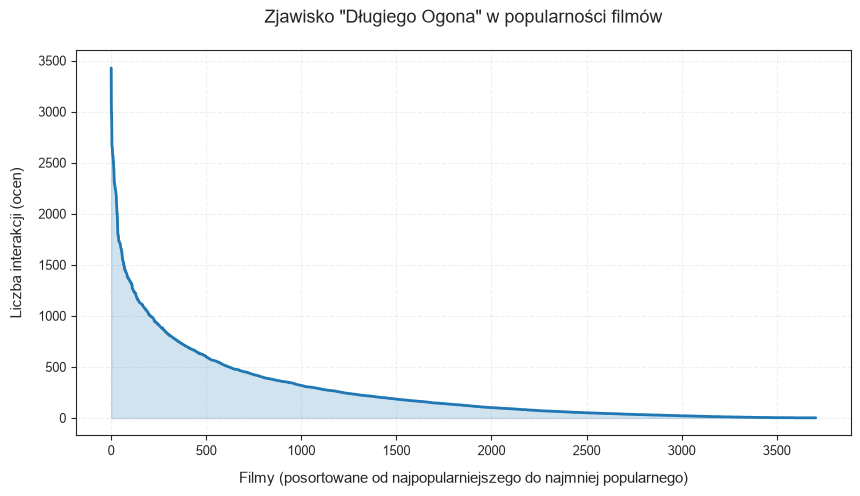

In [ ]:
movie_popularity = df_ratings.groupby('item_id').size().sort_values(ascending=False)
x_range = list(range(len(movie_popularity)))

plt.figure(figsize=(10, 5))
plt.plot(x_range, movie_popularity.values.tolist(), color=ACADEMIC_BLUE, linewidth=2)
plt.fill_between(x_range, 0, movie_popularity, color=ACADEMIC_BLUE, alpha=0.15) # type: ignore
plt.title('Zjawisko "Długiego Ogona" w popularności filmów')
plt.xlabel('Filmy (posortowane od najpopularniejszego do najmniej popularnego)')
plt.ylabel('Liczba interakcji (ocen)')
plt.show()

>Wykres posiada wyraźną asymetrię prawostronną co oznacza, że filmy popularne (tzw. hity kinowe) mają zdecydowaną przewagę w oglądalności, a tytuły niszowe były bardzo rzadko wybierane. Stanowi to poważny problem dla tradycyjnych systemów, które mogłby pogłębić przewagę mniej znanych tytułów


### 4. Rozkład aktywności użytkowników i problem "Zimnego Startu" (Cold Start)

Problem "zimnego startu" pojawia się, gdy system nie posiada wystarczających danych historycznych o użytkowniku, aby wywnioskować jego preferencje.

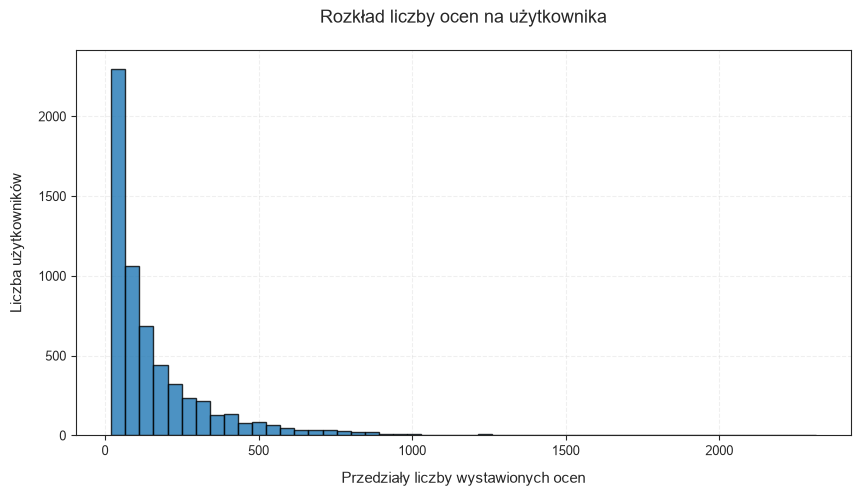

Użytkownicy 'zimni' (<= 20 ocen): 86 (1.42%)


In [113]:
user_counts = df_ratings.groupby('user_id').size()

plt.figure(figsize=(10, 5))
plt.hist(user_counts.tolist(), bins=50, color=ACADEMIC_BLUE, edgecolor='black', alpha=0.8)
plt.title('Rozkład liczby ocen na użytkownika')
plt.xlabel('Przedziały liczby wystawionych ocen')
plt.ylabel('Liczba użytkowników')
plt.show()

cold_start_threshold = 20
cold_users = (user_counts <= cold_start_threshold).sum()
print(f"Użytkownicy 'zimni' (<= {cold_start_threshold} ocen): {cold_users} ({(cold_users/n_users)*100:.2f}%)")


>Najwyższa część histogramu jest skoncentrowana przy osi Y, co oznacza, że największą część stanowią użytkownicy wystawiający relatywnie mało ocen. Odsetek użytkowników "zimnych" (<= 20 ocen) wynosi tu wprawdzie zaledwie 1,42%, jednak należy zaznaczyć, że jest to sztuczny wynik – twórcy zbioru MovieLens odrzucili użytkowników poniżej tego progu. W rzeczywistych systemach VOD odsetek ten jest drastycznie wyższy. Nawet przy tym sztucznym odcięciu widać, że brak gęstej historii dla nowszych użytkowników to wyzwanie dla klasycznego SVD, które potrzebuje gęstych danych do faktoryzacji. Hybrydyzacja, czyli wzbogacenie sieci (np. NCF) o dodatkowe metadane (wiek, płeć, zawód), pozwala modelowi "zgadywać" preferencje nowego użytkownika na podstawie podobieństwa demograficznego, skutecznie mitygując problem zimnego startu.

### 5. Transformacja ocen w „niejawne sprzężenie zwrotne” (Implicit Feedback)

Z uwagi na ewolucję systemów VOD, środowisko testowe dla głębokich algorytmów nieliniowych wymaga binarizacji. Ocena w skali 1-5 (Explicit) powyżej ustalonego progu $\tau$ staje się pozytywną interakcją (ocena 4 lub 5) dostaje "1" (Implicit), inne traktowane są jako sygnał negatywny lub brak sygnału "0".

In [114]:
def binarize_ratings(df, threshold=4):
    df_implicit = df.copy()
    df_implicit['interaction'] = (df_implicit['rating'] >= threshold).astype(int)
    positive_interactions = df_implicit[df_implicit['interaction'] == 1]
    return df_implicit, positive_interactions

df_impl, pos_only = binarize_ratings(df_ratings, threshold=4)

print(f"Transformacja Explicit (1-5) -> Implicit (0/1) dla progu oceny >= 4")
display(df_impl[['user_id', 'item_id', 'rating', 'interaction']].head(7))
print(f"\nLiczba zachowanych interakcji pozytywnych (sygnałów '1'): {len(pos_only)}")

Transformacja Explicit (1-5) -> Implicit (0/1) dla progu oceny >= 4


,user_id,item_id,rating,interaction
0,1,1193,5,1
1,1,661,3,0
2,1,914,3,0
3,1,3408,4,1
4,1,2355,5,1
5,1,1197,3,0
6,1,1287,5,1



Liczba zachowanych interakcji pozytywnych (sygnałów '1'): 575281


>Analizując zjawisko Implicit Feedback należy zauważyć, że nowoczesne platformy (jak Netflix, YouTube) preferują analizę kliknięć i obejrzeń zamiast pytać użytkowników o ocenę z gwiazdek. Użytkownicy często są leniwi i nie oceniają każdego obejrzanego filmu, co prowadzi do błędów. Z kolei sam fakt włączenia filmu jest mocnym sygnałem preferencji. Wybór progu $\tau=4$ zmienia znaczenie analizowanego sygnału z neutralnego "obejrzał" na twarde "bardzo mu się podobało". Odrzucamy w ten sposób filmy włączone przypadkowo lub te, które wywołały negatywne odczucia, co pozwala algorytmom sieci neuronowych i grafowych trenować wyłącznie na wzorcach o wysokiej satysfakcji.

### 6. Modelowanie grafu dwudzielnego (Bipartite Graph Construction)

Dla modeli klasycznych (SVD) reprezentacją jest płaska macierz. Modele grafowe interpretują ten sam zbiór jako nieskierowany graf dwudzielny $\mathcal{G} = (\mathcal{U} \cup \mathcal{I}, \mathcal{E})$, gdzie krawędzie $\mathcal{E}$ istnieją pomiędzy użytkownikami $\mathcal{U}$ a filmami $\mathcal{I}$.

1. Liczba krawędzi w grafie: 575281
2. Średni stopień węzła - Użytkownik: 95.28
3. Średni stopień węzła - Film: 162.83


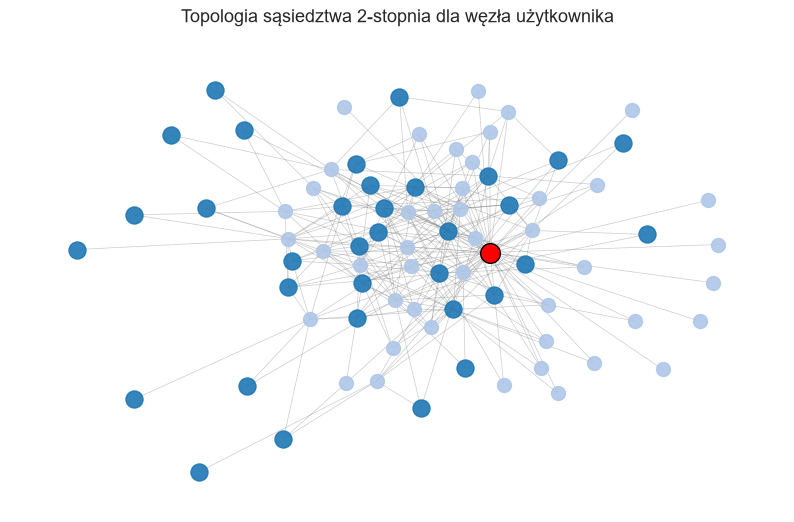

In [115]:
B = nx.Graph()
user_nodes = [f"u_{u}" for u in pos_only['user_id'].unique()]
B.add_nodes_from(user_nodes, bipartite=0)
item_nodes = [f"i_{i}" for i in pos_only['item_id'].unique()]
B.add_nodes_from(item_nodes, bipartite=1)

edges = [(f"u_{row['user_id']}", f"i_{row['item_id']}") for idx, row in pos_only.iterrows()]
B.add_edges_from(edges)

user_degrees = [B.degree[n] for n in user_nodes]
item_degrees = [B.degree[n] for n in item_nodes]

print(f"\n1. Liczba węzłów całkowita: {B.number_of_nodes()}")
print(f"2. Średni stopień węzła - Użytkownik: {np.mean(user_degrees):.2f}")
print(f"3. Średni stopień węzła - Film: {np.mean(item_degrees):.2f}")

# WIZUALIZACJA PODGRAFU (Ego-Graph)
plt.figure(figsize=(10, 6))
seed_user = user_nodes[0]
ego_graph = nx.ego_graph(B, seed_user, radius=2)

if ego_graph.number_of_nodes() > 80:
    neighbors = list(ego_graph.neighbors(seed_user))
    keep_nodes = [seed_user] + neighbors
    remaining = list(set(ego_graph.nodes()) - set(keep_nodes))
    keep_nodes += remaining[:max(0, 80 - len(keep_nodes))]
    ego_graph = ego_graph.subgraph(keep_nodes)

top_nodes = [n for n in ego_graph.nodes if n.startswith('u_')]
bottom_nodes = [n for n in ego_graph.nodes if n.startswith('i_')]
pos = nx.spring_layout(ego_graph, seed=42, k=0.15)

nx.draw_networkx_nodes(ego_graph, pos, nodelist=top_nodes, node_color=ACADEMIC_BLUE, node_size=150, alpha=0.9)
nx.draw_networkx_nodes(ego_graph, pos, nodelist=bottom_nodes, node_color=LIGHT_BLUE, node_size=100, alpha=0.9)
nx.draw_networkx_edges(ego_graph, pos, width=0.5, alpha=0.4, edge_color=ACADEMIC_GRAY)
if seed_user in pos:
    nx.draw_networkx_nodes(ego_graph, pos, nodelist=[seed_user], node_color='red', node_size=200, edgecolors='black')

plt.title(f'Topologia sąsiedztwa 2-stopnia dla węzła użytkownika')
plt.axis('off')
plt.show()

>Interpretując wyliczony średni stopień węzła (ok. 95 dla użytkownika), zauważamy, że pojedynczy widz jest relatywnie słabo podpięty do całej bazy ponad 3700 filmów. Jednakże, jak widać na wykresie Ego-Graphu, informacja w sieci grafowej może przepłynąć od niszowego filmu na obrzeżach do użytkownika w centrum poprzez krawędzie innych, podobnych widzów. Taka propagacja (Message Passing) w modelu LightGCN pozwala algorytmowi agregować preferencje z 2-, 3- a nawet 4-stopnia sąsiedztwa. Różni się to diametralnie od SVD, które traktuje każdą relację punktowo i próbuje szacować globalne cechy ukryte dla całej macierzy bez jawnego uwzględnienia lokalnej topologii powiązań społecznościowych.

### 7. Charakterystyka demograficzna (User Profiling)

Analiza struktury demograficznej udowadnia, że zbiór jest reprezentatywny dla rzeczywistej populacji. Cel: weryfikacja dostępności cech (Side Information), które posłużą jako dodatkowe wejścia łagodzące problem zimnego startu.

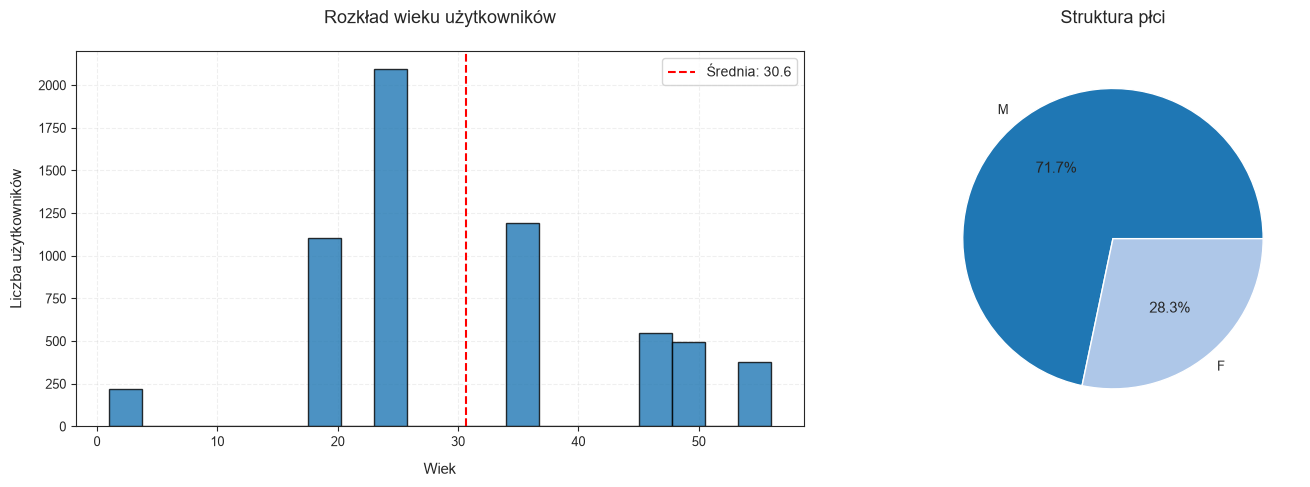

In [118]:
df_users = pd.read_csv(f'{data_dir}/movielens_{DATASET_VERSION}_users.csv')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
age_list = df_users['age'].tolist()
ax1.hist(age_list, bins=20, color=ACADEMIC_BLUE, edgecolor='black', alpha=0.8)
ax1.set_title('Rozkład wieku użytkowników')
ax1.set_xlabel('Wiek')
ax1.set_ylabel('Liczba użytkowników')
ax1.axvline(np.mean(age_list), color='red', linestyle='--', label=f'Średnia: {np.mean(age_list):.1f}')
ax1.legend()

gender_counts = df_users['gender'].value_counts()
ax2.pie(gender_counts.values.tolist(), labels=gender_counts.index.tolist(), autopct='%1.1f%%', colors=[ACADEMIC_BLUE, LIGHT_BLUE])
ax2.set_title('Struktura płci')

plt.tight_layout()
plt.show()

>Analiza danych demograficznych uwidacznia silną koncentrację populacji w określonych segmentach (np. dominacja mężczyzn i osób w wieku około 25-35 lat). Choć taki rozkład odzwierciedla specyfikę historycznej bazy użytkowników internetu w tamtym okresie, stanowi cenną informację (Side Information). Włączenie danych takich jak płeć, wiek czy zawód jako dodatkowej warstwy wejściowej w sztucznej sieci neuronowej (np. w zmodyfikowanej architekturze NCF) pozwala modelowi zredukować problem zimnego startu. Nowy użytkownik w systemie nie otrzymuje już uśrednionych rekomendacji dla całej populacji, lecz od razu dopasowane propozycje bazujące na wzorcach zachowań podobnego do niego profilu demograficznego.

### 8. Dynamika czasowa interakcji (Temporal Dynamics)

Zachowania na platformach VOD podlegają trendom. Analiza rozkładu interakcji w czasie służy dowiedzeniu, że dane mają strukturę sekwencyjną.

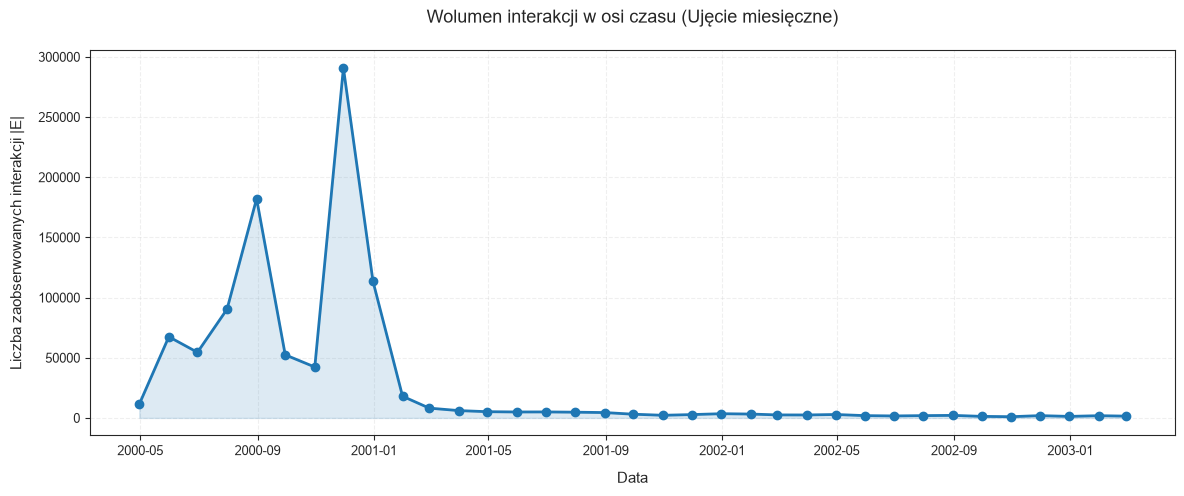

In [ ]:
df_ratings['date'] = pd.to_datetime(df_ratings['timestamp'], unit='s')
temporal_vol = df_ratings.resample('ME', on='date').size()

plt.figure(figsize=(14, 5))
plt.plot(temporal_vol.index, temporal_vol.values, color=ACADEMIC_BLUE, linewidth=2, marker='o')
plt.fill_between(temporal_vol.index, 0, temporal_vol.values, color=ACADEMIC_BLUE, alpha=0.15) # type: ignore
plt.title('Wolumen interakcji w osi czasu (Ujęcie miesięczne)')
plt.xlabel('Data')
plt.ylabel('Liczba zaobserwowanych interakcji |E|')
plt.show()

>Silne wahania i piki widoczne na wykresie osi czasu udowadniają, że preferencje użytkowników i ogólna aktywność na platformie nie są stałe, lecz zależą od trendów, premier czy sezonowości. W związku z tym, stosowanie klasycznego podziału Random Split (losowe wybieranie 20% ocen do testów) jest metodologicznie błędne, ponieważ model mógłby trenować na opiniach z roku 2002, aby przewidzieć co użytkownik obejrzał w roku 2000 (tzw. Data Leakage). Konieczność wdrożenia metodologii Temporal Split (lub Leave-One-Out chronologicznego) gwarantuje, że modele będą rygorystycznie testowane na zdolność przewidywania *przyszłych* zachowań wyłącznie na podstawie danych *historycznych*.